最適化問題
- 最適化問題の分類と典型的な問題と例題

In [5]:
import numpy as np
from gurobipy import  Model, quicksum, GRB, multidict
import intvalpy

In [ ]:
# 線形最適化問題
model = Model("lol")

x1 = model.addVar(name="x1")
x2 = model.addVar(name="x2")
model.update()

model.addConstr(2 * x1+x2 <= 60)
model.addConstr(x1+ 2 *x2 <= 60)
model.setObjective(15*x1 + 18*x2, GRB.MAXIMIZE)
model.optimize()

if model.Status == GRB.Status.OPTIMAL:
    print("Opt.Value =",model.ObjVal)
    for v in model.getVars():
        print(v.VarName,v.X)

Restricted license - for non-production use only - expires 2027-11-29
Gurobi Optimizer version 13.0.2 build v13.0.2rc1 (linux64 - "Ubuntu 22.04.3 LTS")

CPU model: 12th Gen Intel(R) Core(TM) i5-1235U, instruction set [SSE2|AVX|AVX2]
Thread count: 6 physical cores, 12 logical processors, using up to 12 threads

Optimize a model with 2 rows, 2 columns and 4 nonzeros (Max)
Model fingerprint: 0x55e46f11
Model has 2 linear objective coefficients
Coefficient statistics:
  Matrix range     [1e+00, 2e+00]
  Objective range  [2e+01, 2e+01]
  Bounds range     [0e+00, 0e+00]
  RHS range        [6e+01, 6e+01]

Presolve time: 0.02s
Presolved: 2 rows, 2 columns, 4 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    3.3000000e+31   3.000000e+30   3.300000e+01      0s
       2    6.6000000e+02   0.000000e+00   0.000000e+00      0s

Solved in 2 iterations and 0.03 seconds (0.00 work units)
Optimal objective  6.600000000e+02
Opt.Value = 660.0
x1 20.0
x2 20.0


array([[20., 20.],
       [30.,  0.],
       [ 0.,  0.],
       [ 0., 30.]])

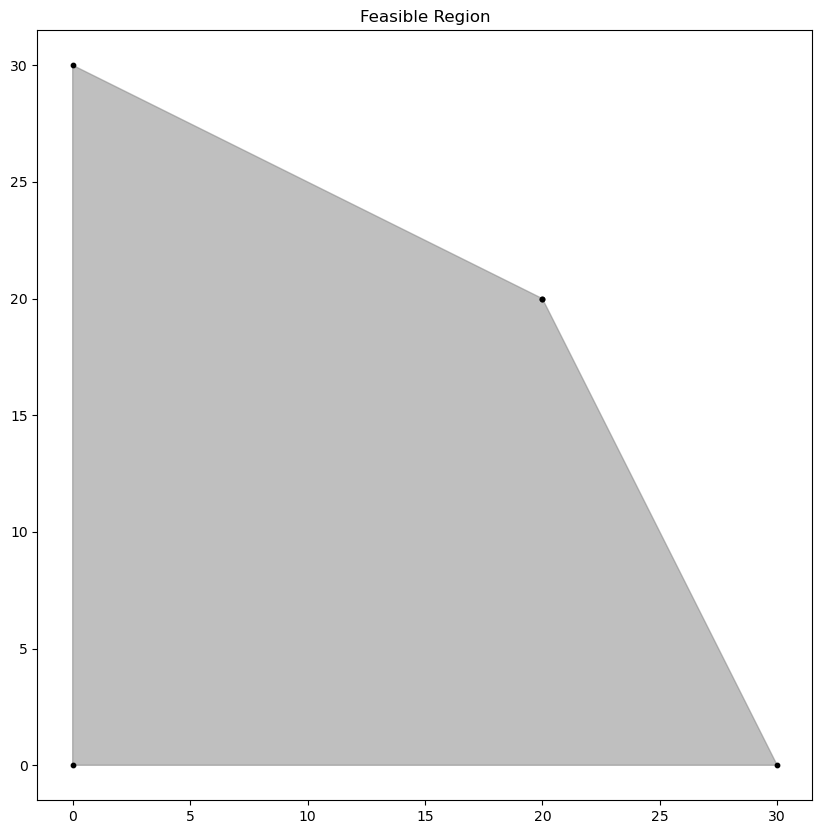

In [ ]:
# 描画
# Ax >= bを書くための準備
A = np.array([[-2,-1],
              [-1,-2],
              [1,0],
              [0,1]])

b = np.array([-60,-60,0,0])

intvalpy.lineqs(A,b,title="Feasible Region",color='gray',alpha=0.5,s = 10,size=(10,10),save= False,show=True)

In [ ]:
# 錐最適化問題
model = Model()
x = model.addVar(name="x")
y = model.addVar(name="y")
z = model.addVar(name="z")

model.update()

model.addConstr(x**2 + y**2 <= z**2)
model.addConstr(2*x + 3*y + 4*z <= 10)
model.setObjective(2*x + 2*y +z, GRB.MAXIMIZE)

model.optimize()

if model.Status == GRB.Status.OPTIMAL:
    print("Opt.Val. = ",model.ObjVal)
    print("(x,y,z) = ",(x.X,y.X,y.X))


Gurobi Optimizer version 13.0.2 build v13.0.2rc1 (linux64 - "Ubuntu 22.04.3 LTS")

CPU model: 12th Gen Intel(R) Core(TM) i5-1235U, instruction set [SSE2|AVX|AVX2]
Thread count: 6 physical cores, 12 logical processors, using up to 12 threads

Optimize a model with 1 rows, 3 columns and 3 nonzeros (Max)
Model fingerprint: 0x8f2748ce
Model has 3 linear objective coefficients
Model has 1 quadratic constraint
Coefficient statistics:
  Matrix range     [2e+00, 4e+00]
  QMatrix range    [1e+00, 1e+00]
  Objective range  [1e+00, 2e+00]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+01, 1e+01]

Presolve time: 0.02s
Presolved: 1 rows, 3 columns, 3 nonzeros
Presolved model has 1 second-order cone constraint
Ordering time: 0.00s

Barrier statistics:
 AA' NZ     : 0.000e+00
 Factor NZ  : 1.000e+00
 Factor Ops : 1.000e+00 (less than 1 second per iteration)
 Threads    : 1

                  Objective                Residual
Iter       Primal          Dual         Primal    Dual     Compl  

In [15]:
# 整数最適化問題
model = Model()
x = model.addVar(vtype= "I",name="x")
y = model.addVar(vtype= "I",name="y")
z = model.addVar(vtype= "I",name="z")

model.update()

model.addConstr(x + y + z ==32)
model.addConstr(2*x + 4*y + 8*z == 80)
model.setObjective(y +z, GRB.MINIMIZE)

model.optimize()

if model.Status == GRB.Status.OPTIMAL:
    print("Opt.Val. = ",model.ObjVal)
    print("(x,y,z) = ",(x.X,y.X,y.X))


Gurobi Optimizer version 13.0.2 build v13.0.2rc1 (linux64 - "Ubuntu 22.04.3 LTS")

CPU model: 12th Gen Intel(R) Core(TM) i5-1235U, instruction set [SSE2|AVX|AVX2]
Thread count: 6 physical cores, 12 logical processors, using up to 12 threads

Optimize a model with 2 rows, 3 columns and 6 nonzeros (Min)
Model fingerprint: 0xb3e766db
Model has 2 linear objective coefficients
Variable types: 0 continuous, 3 integer (0 binary)
Coefficient statistics:
  Matrix range     [1e+00, 8e+00]
  Objective range  [1e+00, 1e+00]
  Bounds range     [0e+00, 0e+00]
  RHS range        [3e+01, 8e+01]

Presolve removed 2 rows and 3 columns
Presolve time: 0.00s
Presolve: All rows and columns removed

Explored 0 nodes (0 simplex iterations) in 0.02 seconds (0.00 work units)
Thread count was 1 (of 12 available processors)

Solution count 1: 4 

Optimal solution found (tolerance 1.00e-04)
Best objective 4.000000000000e+00, best bound 4.000000000000e+00, gap 0.0000%
Opt.Val. =  4.0
(x,y,z) =  (28.0, 2.0, 2.0)
